In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('.'))

from xso.parscans import run_xso_parscan,run_xso_stabilityscan

from cariaco_ssm_setup import model, model_setup, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup, extract_steady_state_seed,
)
from parscan_plots import (
    plot_cost_heatmap,
    plot_model_vs_obs_boxplots, summarize_best_fit,
)

In [2]:
REGIME = 'all'
obs_vec, labels, bin_defs, monthly_df, forcing = load_cariaco_targets(regime=REGIME)

print(f"Observation targets (regime='{REGIME}'):")
for lab, val in zip(labels, obs_vec):
    print(f"  {lab:20s}: {val:.5f}")
print(f"Months in filtered dataset: {len(monthly_df)}")
print(f"Regime forcing:")
print(f"  Inflow__FN = {forcing['Inflow__FN']:.4f}  mmol N m-2 d-1")
print(f"  Inflow__de = {forcing['Inflow__de']:.2f}  m")
print(f"  (F_N/d_e   = {forcing['Inflow__FN']/forcing['Inflow__de']:.6f}  mmol N m-3 d-1)")

Observation targets (regime='all'):
  Pico (<2 µm)        : 0.09698
  Nano (2-20 µm)      : 0.08512
  Micro (>20 µm)      : 0.19977
  Zoo >200 µm         : 0.05938
  Zoo >500 µm         : 0.03302
  NO3                 : 1.46705
  PP                  : 0.43247
  Export              : 3.18267
Months in filtered dataset: 255
Regime forcing:
  Inflow__FN = 2.6834  mmol N m-2 d-1
  Inflow__de = 45.58  m
  (F_N/d_e   = 0.058877  mmol N m-3 d-1)


In [3]:
# Which parameters to scan, their ranges, and grid resolution
P1_NAME   = 'GGE__gge'
P1_LABEL  = 'Gross growth efficiency GGE (–)'
P1_VALUES = np.linspace(0.05, 0.55, 50)
P2_NAME   = 'Grazing__KsZ'
P2_LABEL  = 'Zooplankton half-saturation K_sZ (mmol N m⁻³)'
P2_VALUES = np.linspace(0.3, 10.0, 50)
# Scan runtime settings
N_PROCESSES = 20
AVG_WINDOW  = 1000   # days at tail of IVP to average for steady-state cost
print(f"2D scan: {P1_NAME} ({len(P1_VALUES)} pts)  x  {P2_NAME} ({len(P2_VALUES)} pts)")
print(f"Total runs: {len(P1_VALUES) * len(P2_VALUES)}")
print(f"  GGE spans {P1_VALUES.min():.2f} – {P1_VALUES.max():.2f}")
print(f"  KsZ spans {P2_VALUES.min():.2f} – {P2_VALUES.max():.2f} mmol N m⁻³ "
      f"(low = strong grazing at low prey density)")

2D scan: DetritusRemin__k_remin (40 pts)  x  GGE__f_egest_D (40 pts)
Total runs: 1600
  k_remin spans 0.020 – 0.500 d⁻¹
  f_egest_D spans 0.05 – 0.95 (low = more sloppy-feeding direct recycling to N)


In [4]:
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_slim',
    param_name=P1_NAME,
    param_values=P1_VALUES,
    param_name2=P2_NAME,
    param_values2=P2_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': AVG_WINDOW},
)

PROGRESS: Completed 40/40 outer points. (DetritusRemin__k_remin = 0.5).

2D Scan complete. Total Time taken: 524.32817 seconds.


In [5]:
print(scan_results)

<xarray.Dataset> Size: 3MB
Dimensions:                         (GGE__f_egest_D: 40,
                                     DetritusRemin__k_remin: 40, time: 1,
                                     phyto: 12, zoo: 12)
Coordinates:
  * GGE__f_egest_D                  (GGE__f_egest_D) float64 320B 0.05 ... 0.95
  * DetritusRemin__k_remin          (DetritusRemin__k_remin) float64 320B 0.0...
  * time                            (time) float64 8B 4.999e+03
  * phyto                           (phyto) float64 96B 0.5 0.862 ... 200.0
  * zoo                             (zoo) float64 96B 5.0 8.62 ... 2e+03
    Inflow__FN                      float64 8B 2.683
    Inflow__de                      float64 8B 45.58
Data variables: (12/60)
    DetritusSink__sinking_value     (GGE__f_egest_D, DetritusRemin__k_remin, time) float64 13kB ...
    Detritus__value                 (GGE__f_egest_D, DetritusRemin__k_remin, time) float64 13kB ...
    Growth__uptake_value            (GGE__f_egest_D, DetritusRemin__

In [6]:
seed_ds, iv_map = extract_steady_state_seed(scan_results, avg_window=AVG_WINDOW)


stability_results = run_xso_stabilityscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_stability',
    param_name=P1_NAME,
    param_values=P1_VALUES,
    param_name2=P2_NAME,
    param_values2=P2_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
    initial_values_ds=seed_ds,
    iv_mapping=iv_map,
)

PROGRESS: Completed 40/40 outer points. (DetritusRemin__k_remin = 0.5).

2D Stability Scan complete. Total Time taken: 17.98308 seconds.


In [7]:
cost_grid, model_grid = compute_cost_grid(
    stability_results,
    phyto_esd=phyto_esd,
    zoo_esd=zoo_esd,
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    dim1_name=P1_NAME,
    dim2_name=P2_NAME,    avg_window=None,
    neg_tolerance=1e-6,
    clip_small_negatives=True,
    require_stable=False,
)

In [8]:
best = find_best_fit(cost_grid, model_grid, scan_results, P1_NAME, P2_NAME)

default = {
    'val1': get_default_from_setup(model_setup, P1_NAME),
    'val2': get_default_from_setup(model_setup, P2_NAME),
}

title_info = (f"{P1_NAME}={best['val1']:.4f}, "
              f"{P2_NAME}={best['val2']:.4f}, "
              f"cost={best['cost']:.3f}")

print(f"\n--- Best fit ---")
print(f"  {P1_LABEL}: {best['val1']:.5f}")
print(f"  {P2_LABEL}: {best['val2']:.5f}")
print(f"  Cost (NRMSRE): {best['cost']:.4f}")


--- Best fit ---
  Remineralization rate k_remin (d⁻¹): 0.13077
  Fraction of zoo egestion routed to D (–): 0.05000
  Cost (NRMSRE): 6.6807


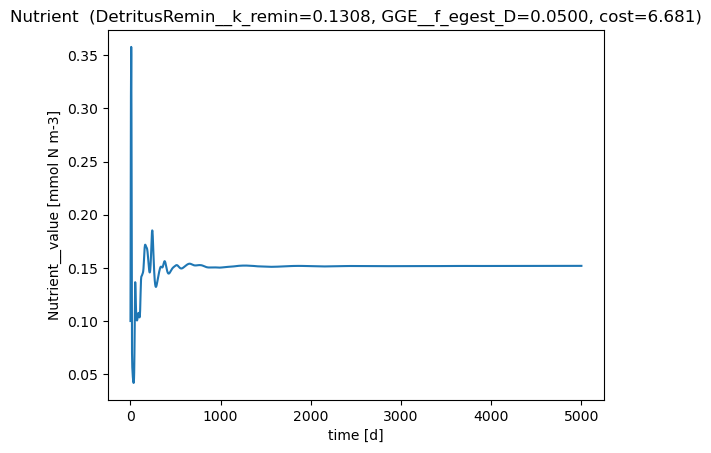

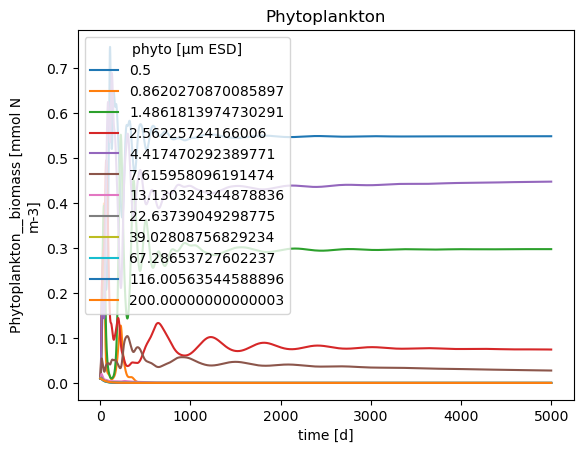

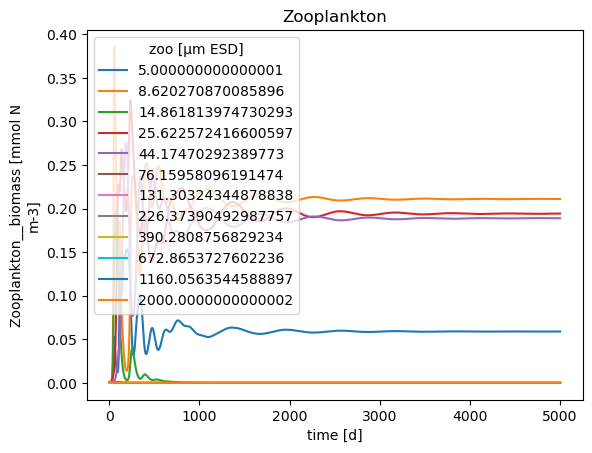

In [9]:
from cariaco_ssm_setup import model_setup_slim
from parscan_utils import run_single_point

best_run = run_single_point(
    model, model_setup_slim,
    scan_params={P1_NAME: best['val1'], P2_NAME: best['val2']},
    fixed_overrides=forcing,
)

best_run['Nutrient__value'].plot.line(x='time')
plt.title(f'Nutrient  ({title_info})')
plt.show()

best_run['Phytoplankton__biomass'].plot.line(x='time')
plt.title('Phytoplankton')
plt.show()

best_run['Zooplankton__biomass'].plot.line(x='time')
plt.title('Zooplankton')
plt.show()

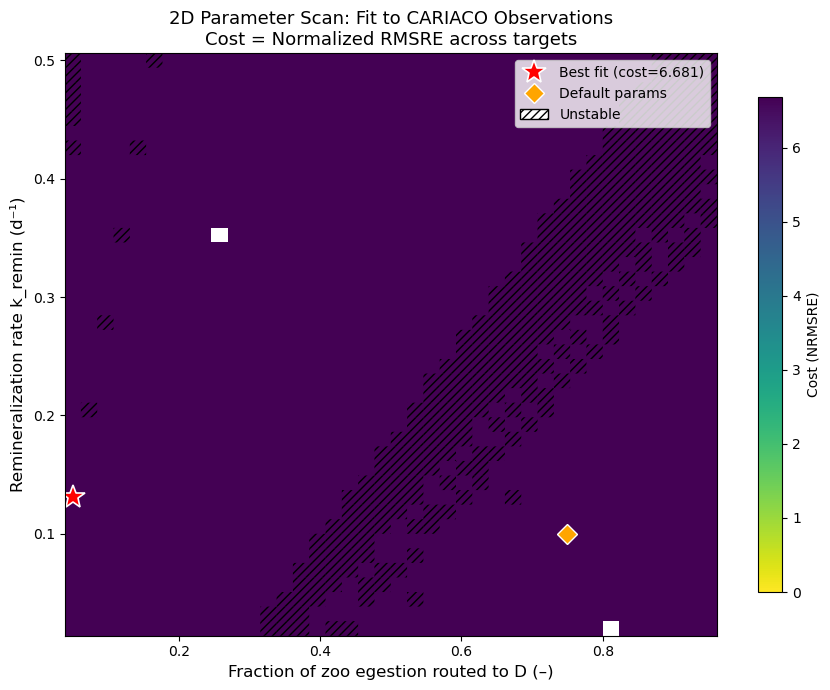

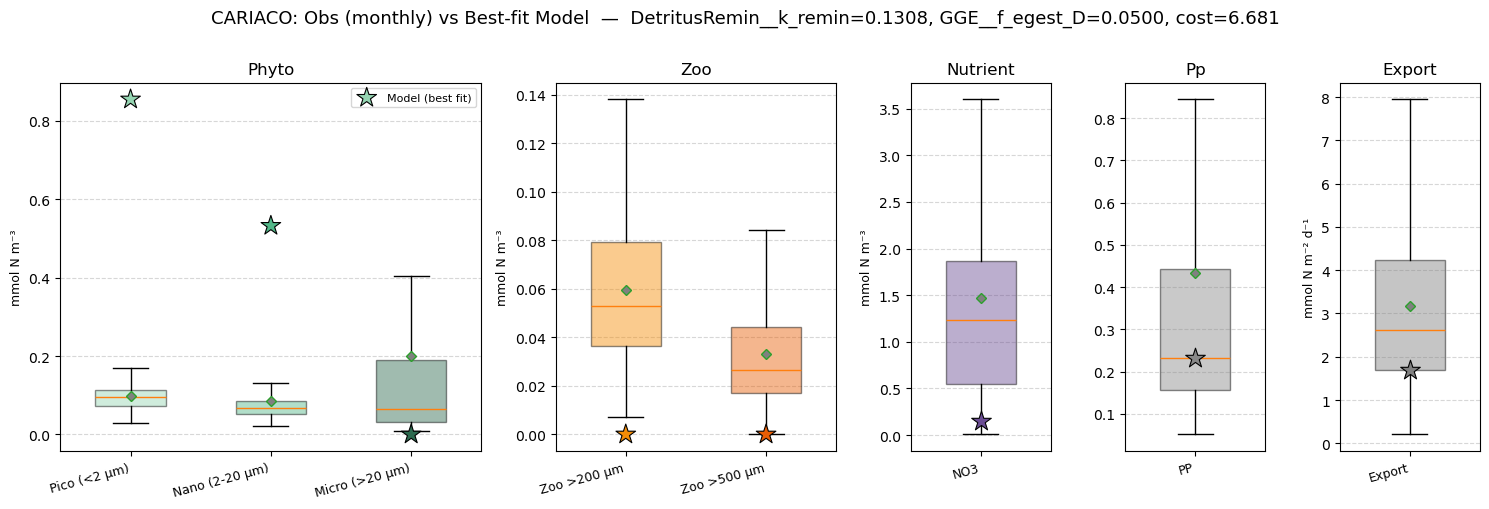

In [10]:
stable_mask = (stability_results['stability'] == 'stable').values

fig1 = plot_cost_heatmap(
    cost_grid, P1_VALUES, P2_VALUES, P1_LABEL, P2_LABEL, best,
    default=default,
    stable_mask=stable_mask,
)
plt.show()

fig3 = plot_model_vs_obs_boxplots(best['model_vec'], monthly_df, bin_defs,
                                  title_info=title_info)
plt.show()

In [11]:
# Source - https://stackoverflow.com/a/24542498
# Posted by ZSG, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-23, License - CC BY-SA 4.0

def fullprint(*args, **kwargs):
  from pprint import pprint
  import numpy
  opt = numpy.get_printoptions()
  numpy.set_printoptions(threshold=numpy.inf)
  pprint(*args, **kwargs)
  numpy.set_printoptions(**opt)


In [12]:
fullprint(stable_mask)


array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True, False, False, False,  True, False, False,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True, False, False, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False, False, False,  True,  True,
        False,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True],
       [ True,  True,  True,  True,  

In [13]:
summary = summarize_best_fit(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    labels=labels,
    cost=best['cost'],
)


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 6.6807
     Component  Obs_Mean  Model_BestFit   Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        0.85525 8.81897    781.89716
Nano (2-20 µm)   0.08512        0.53262 6.25758    525.75785
Micro (>20 µm)   0.19977        0.00000 0.00000   -100.00000
   Zoo >200 µm   0.05938        0.00000 0.00000   -100.00000
   Zoo >500 µm   0.03302        0.00000 0.00000   -100.00000
           NO3   1.46705        0.15270 0.10409    -89.59124
            PP   0.43247        0.23343 0.53976    -46.02374
        Export   3.18267        1.69805 0.53353    -46.64681


In [14]:
best_run

<xarray.Dataset> Size: 2MB
Dimensions:                         (time: 5000, phyto: 12, zoo: 12, clock: 2)
Coordinates:
  * time                            (time) float64 40kB 0.0 1.0 ... 4.999e+03
  * phyto                           (phyto) float64 96B 0.5 0.862 ... 200.0
  * zoo                             (zoo) float64 96B 5.0 8.62 ... 2e+03
  * clock                           (clock) int64 16B 0 1
Data variables: (12/64)
    Core__solver_type               <U9 36B 'solve_ivp'
    DetritusRemin__detritus         <U1 4B 'D'
    DetritusRemin__k_remin          float64 8B 0.1308
    DetritusRemin__nutrient         <U1 4B 'N'
    DetritusSink__detritus          <U1 4B 'D'
    DetritusSink__sinking_rate      float64 8B 0.1
    ...                              ...
    ZooMortality__rate              float64 8B 0.1
    Zooplankton__biomass            (zoo, time) float64 480kB 0.001 ... 0.0
    Zooplankton__biomass_init       (zoo) float64 96B 0.001 0.001 ... 0.001
    Zooplankton__biomass_label      <U1 4B 'Z'
    Zooplankton__zoo_esd_index      (zoo) float64 96B 5.0 8.62 ... 2e+03
    Zooplankton__zoo_esd_label      <U7 28B 'zoo_esd'

In [15]:
cell = stability_results.sel({P1_NAME: best['val1'], P2_NAME: best['val2']},
                             method='nearest').isel(time=-1)

# Volumetric rates [mmol N m-3 d-1]
FN_per_de  = float(cell['Inflow__FN']) / float(cell['Inflow__de'])
export_vol = float(cell['DetritusSink__sinking_value'])
fish_P     = float(cell['FishGrazing__fish_graze_phyto_value'].sum('phyto'))
fish_Z     = float(cell['FishGrazing__fish_graze_zoo_value'].sum('zoo'))
zoo_closure_export = float(cell['ZooMortality__mortality_value'].sum('zoo')) \
                   - float(cell['ZooMortality__mortality_to_D_value'])

lhs = FN_per_de
rhs = export_vol + fish_P + fish_Z + zoo_closure_export
print(f"F_N/d_e     = {lhs:.6f}")
print(f"Losses sum  = {rhs:.6f}")
print(f"  sinking       : {export_vol:.6f}")
print(f"  fish on P     : {fish_P:.6f}")
print(f"  fish on Z     : {fish_Z:.6f}")
print(f"  zoo closure   : {zoo_closure_export:.6f}")
print(f"Residual    = {lhs-rhs:.2e}")

# And the f-ratio interpretation:
pp_total = float(cell['Growth__uptake_value'].sum('phyto'))
print(f"\nTotal PP    = {pp_total:.6f}")
print(f"New PP      = {FN_per_de:.6f}  (≡ F_N/d_e)")
print(f"Regen PP    = {pp_total - FN_per_de:.6f}")
print(f"f-ratio     = {FN_per_de / pp_total:.3f}")

F_N/d_e     = 0.058877
Losses sum  = 0.058877
  sinking       : 0.037257
  fish on P     : 0.000090
  fish on Z     : 0.000066
  zoo closure   : 0.021464
Residual    = 6.94e-18

Total PP    = 0.233431
New PP      = 0.058877  (≡ F_N/d_e)
Regen PP    = 0.174554
f-ratio     = 0.252
